In [3]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import matplotlib as mpl
from astropy import units
from astropy import constants as const
from matplotlib.patches import Rectangle
from matplotlib.animation import FuncAnimation
from  IPython.display import HTML
from scipy.optimize import curve_fit
from scipy.special import wofz
from scipy.interpolate import interp1d
import time as tt


mpl.rcParams['font.size'] = 16
mpl.rcParams['image.cmap']="Greys_r" 
mpl.rcParams['image.origin']= "lower"

In [4]:
sst4 = h5py.File("/mn/stornext/d19/RoCS/svenwe/lecture/AST5770/data/obssun_sst4/obssun_sst4.h5", "r")
sst4.keys()

<KeysViewHDF5 ['description', 'imagescale', 'intensity', 'lambda0', 'time', 'time_s', 'unit', 'wavelength', 'x', 'y']>

In [5]:
intensity = sst4["intensity"][:]
wavelength = sst4["wavelength"][:]
time = sst4["time"][:]
time_s = sst4["time_s"][:]
x = sst4["x"][:]
y = sst4["y"][:]
c = const.c

In [6]:
# finding central wavelength of Fe I line
FeI = np.mean(wavelength)
thr = 1e-3
search = np.logical_and(wavelength > FeI - thr, wavelength < FeI + thr)
line_core_idx = np.where(search == True)[0][0]
central_lmbda = wavelength[line_core_idx]
print(f"Line core index: {line_core_idx}")
print(f"Central wavelength of Fe I line: {central_lmbda} nm")

Line core index: 7
Central wavelength of Fe I line: 617.3367919921875 nm


In [7]:
# for frame in range(time.size):  
#     fig, ax = plt.subplots(figsize=(8, 6))
#     ax.set_title(f"$\lambda$ = {central_lmbda: .2f} nm, t[{frame}] = {time_s[frame]: .3f} s")
#     ax.set_xlabel("x [arcsec]"); ax.set_ylabel("y [arcsec]")
#     im = ax.imshow(intensity[frame, line_core_idx, :, :], origin="lower", vmin  = intensity.min(), vmax = intensity.max(), extent = [np.min(x), np.max(x), np.min(y), np.max(y)])
#     fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Intensity [counts]")
#     plt.tight_layout()
#     # plt.savefig(f"figures/intensity/intensity_{frame:04d}.png")

## 01 Defining subfields in FOV

In [8]:
xy_A_min = 394; xy_A_max = 480
xy_B_min = 118; xy_B_max = 204
xy_C_min = 220; xy_C_max = 306

x_subfield_A = sst4["x"][xy_A_min:xy_A_max]; y_subfield_A = sst4["y"][xy_A_min:xy_A_max]
subfield_A = sst4["intensity"][:, :, xy_A_min:xy_A_max, xy_A_min:xy_A_max]

x_subfield_B = sst4["x"][xy_B_min:xy_B_max]; y_subfield_B = sst4["y"][xy_B_min:xy_B_max]
subfield_B = sst4["intensity"][:, :, xy_B_min:xy_B_max, xy_B_min:xy_B_max]

x_subfield_C = sst4["x"][xy_C_min:xy_C_max]; y_subfield_C = sst4["y"][xy_C_min:xy_C_max]
subfield_C = sst4["intensity"][:, :, xy_C_min:xy_C_max, xy_C_min:xy_C_max]

In [9]:
print(f"Full fov: ({x[-1]-x[0]: .3f}, {y[-1]-y[0]: .3f}) arcsec")

print(f"FOV, A: ({x[xy_A_max]-x[xy_A_min]: .3f}, {y[xy_A_max]-y[xy_A_min]: .3f}) arcsec")

print(f"FOV, B: ({x[xy_B_max]-x[xy_B_min]: .3f}, {y[xy_B_max]-y[xy_B_min]: .3f}) arcsec")

print(f"Wavelength range: {(wavelength[0]*units.nm).to(units.AA): .2f} - {(wavelength[-1]*units.nm).to(units.AA): .2f}")

Full fov: ( 29.638,  29.638) arcsec
FOV, A: ( 4.988,  4.988) arcsec
FOV, B: ( 4.988,  4.988) arcsec
Wavelength range:  6173.01 Angstrom -  6174.01 Angstrom


## 02 Intensity maps

### 2.1 Subfield A and B

In [ ]:
# for frame in range(time.size):
#     fig, ax = plt.subplots(1, 3, figsize = (20, 6))
#     fig.suptitle(f"$\lambda$ = {central_lmbda: .2f} nm, t[{frame}] = {time_s[frame]: .3f} s")
#     fig.supxlabel("x [arcsec]"); fig.supylabel("y [arcsec]")

#     im_fov = ax[0].imshow(intensity[frame, line_core_idx, :, :], origin="lower", vmin  = intensity.min(), vmax = intensity.max(), extent = [np.min(x), np.max(x), np.min(y), np.max(y)])
#     fig.colorbar(im_fov, ax=ax[0], fraction=0.046, pad=0.04)
    
#     ax[0].add_patch(Rectangle((sst4["x"][xy_A_min], sst4["y"][xy_A_min]), sst4["x"][xy_A_max]- sst4["x"][xy_A_min], sst4["y"][xy_A_max]- sst4["y"][xy_A_min], fill=None, edgecolor="red", linewidth=2))
#     ax[0].add_patch(Rectangle((sst4["x"][xy_B_min], sst4["y"][xy_B_min]), sst4["x"][xy_B_max]- sst4["x"][xy_B_min], sst4["y"][xy_B_max]- sst4["y"][xy_B_min], fill=None, edgecolor="red", linewidth=2))
#     ax[0].text(sst4["x"][xy_A_max] - 1.5, sst4["y"][xy_A_max] - 1.5, "A", color="red", fontsize = 14)
#     ax[0].text(sst4["x"][xy_B_max] - 1.5, sst4["y"][xy_B_max] - 1.5, "B", color="red", fontsize = 14)

#     A = ax[1].imshow(subfield_A[frame, line_core_idx], origin="lower", vmin = subfield_A.min(), vmax = subfield_A.max(), extent = [np.min(x_subfield_A), np.max(x_subfield_A), np.min(y_subfield_A), np.max(y_subfield_A)])
#     fig.colorbar(A, ax=ax[1], fraction=0.046, pad=0.04)
#     ax[1].text(sst4["x"][xy_A_max] - .5, sst4["y"][xy_A_max] - .5, "A", color="white", fontsize = 24)

#     B = ax[2].imshow(subfield_B[frame, line_core_idx], origin="lower", vmin = subfield_B.min(), vmax = subfield_B.max(), extent = [np.min(x_subfield_B), np.max(x_subfield_B), np.min(y_subfield_B), np.max(y_subfield_B)])
#     fig.colorbar(B, ax=ax[2], label="Intensity [counts]", fraction=0.046, pad=0.04)
#     ax[2].text(sst4["x"][xy_B_max] - .5, sst4["y"][xy_B_max] - .5, "B", color="white", fontsize = 24)
#     plt.tight_layout()
#     plt.savefig(f"figures/intensity_subfields/intensity_{frame:04d}.png")

### 2.2 Subfield A, B and C

In [14]:
# for frame in range(time.size):
#     fig, ax = plt.subplots(2, 2, figsize = (18, 18), constrained_layout=True)
#     fig.suptitle(f"$\lambda$ = {central_lmbda: .2f} nm, t[{frame}] = {time_s[frame]: .3f} s")
#     fig.supxlabel("x [arcsec]"); fig.supylabel("y [arcsec]")

#     im_fov = ax[0, 0].imshow(intensity[frame, line_core_idx, :, :], origin="lower", vmin  = intensity.min(), vmax = intensity.max(), extent = [np.min(x), np.max(x), np.min(y), np.max(y)])
#     ax[0, 0].add_patch(Rectangle((sst4["x"][xy_A_min], sst4["y"][xy_A_min]), sst4["x"][xy_A_max]- sst4["x"][xy_A_min], sst4["y"][xy_A_max]- sst4["y"][xy_A_min], fill=None, edgecolor="red", linewidth=2))
#     ax[0, 0].add_patch(Rectangle((sst4["x"][xy_B_min], sst4["y"][xy_B_min]), sst4["x"][xy_B_max]- sst4["x"][xy_B_min], sst4["y"][xy_B_max]- sst4["y"][xy_B_min], fill=None, edgecolor="red", linewidth=2))
#     ax[0, 0].add_patch(Rectangle((sst4["x"][xy_C_min], sst4["y"][xy_C_min]), sst4["x"][xy_C_max]- sst4["x"][xy_C_min], sst4["y"][xy_C_max]- sst4["y"][xy_C_min], fill=None, edgecolor="red", linewidth=2))
#     ax[0, 0].text(sst4["x"][xy_A_max] - 1.5, sst4["y"][xy_A_max] - 1.5, "A", color="red", fontsize = 14)
#     ax[0, 0].text(sst4["x"][xy_B_max] - 1.5, sst4["y"][xy_B_max] - 1.5, "B", color="red", fontsize = 14)
#     ax[0, 0].text(sst4["x"][xy_C_max] - 1.5, sst4["y"][xy_C_max] - 1.5, "C", color="red", fontsize = 14)

#     A = ax[0, 1].imshow(subfield_A[frame, line_core_idx], origin="lower", vmin = intensity.min(), vmax = intensity.max(), extent = [np.min(x_subfield_A), np.max(x_subfield_A), np.min(y_subfield_A), np.max(y_subfield_A)])
#     fig.colorbar(A, ax=ax[0, 1], label="Intensity [counts]", fraction=0.046, pad=0.04)
#     ax[0, 1].text(sst4["x"][xy_A_max] - .5, sst4["y"][xy_A_max] - .5, "A", color="white", fontsize = 24)

#     B = ax[1, 0].imshow(subfield_B[frame, line_core_idx], origin="lower", vmin = intensity.min(), vmax = intensity.max(), extent = [np.min(x_subfield_B), np.max(x_subfield_B), np.min(y_subfield_B), np.max(y_subfield_B)])
#     ax[1, 0].text(sst4["x"][xy_B_max] - .5, sst4["y"][xy_B_max] - .5, "B", color="white", fontsize = 24)

#     C = ax[1, 1].imshow(subfield_C[frame, line_core_idx], origin="lower", vmin = intensity.min(), vmax = intensity.max(), extent = [np.min(x_subfield_C), np.max(x_subfield_C), np.min(y_subfield_C), np.max(y_subfield_C)])
#     fig.colorbar(C, ax=ax[1, 1], label="Intensity [counts]", fraction=0.046, pad=0.04)
#     ax[1, 1].text(sst4["x"][xy_C_max] - .5, sst4["y"][xy_C_max] - .5, "C", color="white", fontsize = 24)

# #     plt.tight_layout()
#     plt.savefig(f"figures/intensity_A_B_C/intensity_A_B_C_{frame:04d}.png")

### 2.3 Intensity masking

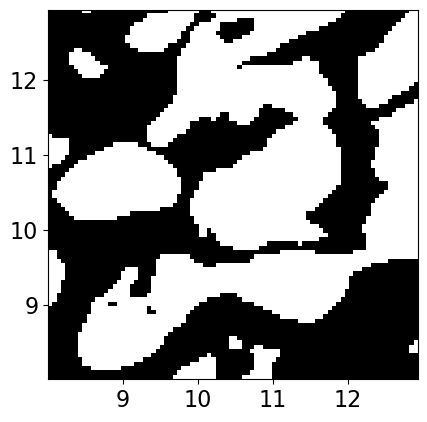

In [21]:
cut_off_intensity = intensity.max() / 2


def intensity_matrix(intensity, cut_off_intensity):
    """
    Create a mask of the intensity matrix where the intensity is above the cut-off value.
    """
    return np.where(intensity > cut_off_intensity, 1, 0)

plt.imshow(intensity_matrix(subfield_A[0, line_core_idx], cut_off_intensity), origin="lower", extent = [np.min(x_subfield_A), np.max(x_subfield_A), np.min(y_subfield_A), np.max(y_subfield_A)])

In [28]:
# intensity_mask_A = intensity_matrix(subfield_A[:, line_core_idx, :], cut_off_intensity)
# intensity_mask_B = intensity_matrix(subfield_B[:, line_core_idx, :], cut_off_intensity)
# intensity_mask_C = intensity_matrix(subfield_C[:, line_core_idx, :], cut_off_intensity)

# np.save("intensity_mask_A.npy", intensity_mask_A)
# np.save("intensity_mask_B.npy", intensity_mask_B)
# np.save("intensity_mask_C.npy", intensity_mask_C)

In [60]:
intensity_mask_A = np.load("intensity_mask_A.npy")
intensity_mask_B = np.load("intensity_mask_B.npy")
intensity_mask_C = np.load("intensity_mask_C.npy")

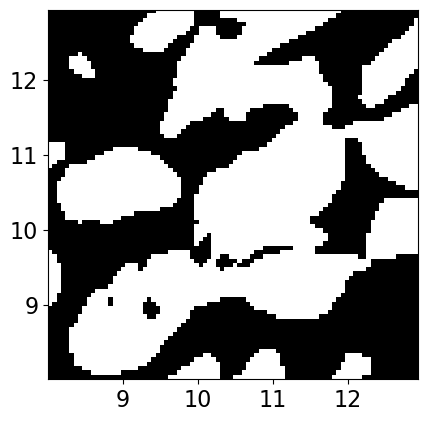

In [61]:
plt.imshow(intensity_mask_A[1], origin="lower", extent = [np.min(x_subfield_A), np.max(x_subfield_A), np.min(y_subfield_A), np.max(y_subfield_A)])

## 03 Curve fit

### 3.1 Fitting Voigt to line profiles

In [32]:
def _voigt(x, amplitude, center, sigma, gamma, background):
    z = ((x - center) + 1j * gamma) / (sigma * np.sqrt(2))
    return amplitude * np.real(wofz(z)) / (sigma * np.sqrt(2 * np.pi)) + background

In [33]:
def _fit_voigt(x_data, y_data, nump, thr):
    # Create the interpolator using linear interpolation
    interpolator = interp1d(x_data, y_data, kind='linear')

    # Use the interpolator to compute y values at new x points
    x_interpolated = np.linspace(x_data.min(), x_data.max(), nump)
    y_interpolated = interpolator(x_interpolated)

    # Parameters for curve fit
    background_level_guess = np.max(y_data)                             # Baseline level
    amplitude_guess = - (np.max(y_data) - np.min(y_data))    # Dip depth
    mean_guess = np.mean(wavelength)                                               # Center of the dip

    # Find FWHM
    peak_max = np.max(y_data) - np.min(y_data)
    half_max = peak_max / 2 + np.min(y_data)
    indices = np.logical_and(y_interpolated > half_max - thr, y_interpolated < half_max + thr)
    search = np.where(indices == True)[0]
    if search.size < 2:
        print("No FWHM found")
    fwhm = x_interpolated[search[-1]] - x_interpolated[search[0]]
    sigma_guess =  fwhm       # Width of the Gaussian component
    gamm_guess = sigma_guess          # Width of the Lorentzian component

    # Initial guesses for curve fitting parameters
    initial_guesses = [amplitude_guess, mean_guess, sigma_guess, gamm_guess, background_level_guess]

    # Fit the Voigt profile
    popt, pcov = curve_fit(_voigt, x_interpolated, y_interpolated, p0=initial_guesses, maxfev=5000)
    return x_interpolated, _voigt(x_interpolated, *popt)

### 3.2 Fitting Gaussian to line profiles

In [34]:
def _gaussian(x, amplitude, mean, sigma, background):
    return amplitude * np.exp(-((x - mean) ** 2) / (2 * sigma ** 2)) + background

In [35]:
def _fit_gaussian(x_data, y_data, nump, thr):
    # Create the interpolator using linear interpolation
    interpolator = interp1d(x_data, y_data, kind='linear')

    # Use the interpolator to compute y values at new x points
    x_interpolated = np.linspace(x_data.min(), x_data.max(), nump)
    y_interpolated = interpolator(x_interpolated)

    # Parameters for curve fit
    background_level_guess = np.max(y_data)                  # Baseline level
    amplitude_guess = - (np.max(y_data) - np.min(y_data))    # Dip depth
    mean_guess = np.mean(wavelength)                                               

    # Find FWHM
    peak_max = np.max(y_data) - np.min(y_data)
    half_max = peak_max / 2 + np.min(y_data)
    indices = np.logical_and(y_interpolated > half_max - thr, y_interpolated < half_max + thr)
    search = np.where(indices == True)[0]
    if search.size < 2:
        print("No FWHM found")

    fwhm = x_interpolated[search[-1]] - x_interpolated[search[0]]
    sigma_guess =  fwhm       # Width of the Gaussian component

    # Initial guesses for curve fitting parameters
    initial_guesses = [amplitude_guess, mean_guess, sigma_guess, background_level_guess]

    # Fit the Gaussian profile
    popt, pcov = curve_fit(_gaussian, x_interpolated, y_interpolated, p0=initial_guesses, maxfev=5000)
    return x_interpolated, _gaussian(x_interpolated, *popt)

## 04 Average intensity profiles

### 4.1 Comparison betwewen Gaussian and Voigt profiles

Voigt fit time: 0.0238 s
Gaussian fit time: 0.0023 s


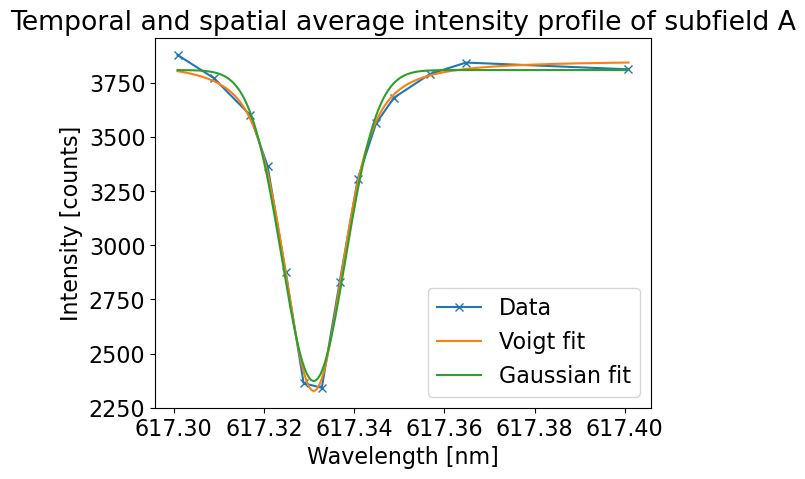

In [36]:
A_intensity_avg = np.average(subfield_A, axis=(0, 2, 3))
A_voigt_t0 = tt.time()
x_voigt, A_voigt_avg = _fit_voigt(wavelength, A_intensity_avg, nump = 1000, thr = 5)
A_voigt_tf = tt.time() 
print(f"Voigt fit time: {A_voigt_tf - A_voigt_t0:.4f} s")

A_gaussian_t0 = tt.time()
x_gaussian, A_gaussian_avg = _fit_gaussian(wavelength, A_intensity_avg, nump = 1000, thr = 5)
A_gaussian_tf = tt.time()
print(f"Gaussian fit time: {A_gaussian_tf - A_gaussian_t0:.4f} s")

plt.plot(wavelength, A_intensity_avg, marker = "x", label="Data")
plt.plot(x_voigt, A_voigt_avg, label="Voigt fit")
plt.plot(x_gaussian, A_gaussian_avg, label="Gaussian fit")
plt.title("Temporal and spatial average intensity profile of subfield A")
plt.xlabel("Wavelength [nm]")
plt.ylabel("Intensity [counts]")
plt.legend()
plt.show()

Voigt fit time: 0.0287 s
Gaussian fit time: 0.0021 s


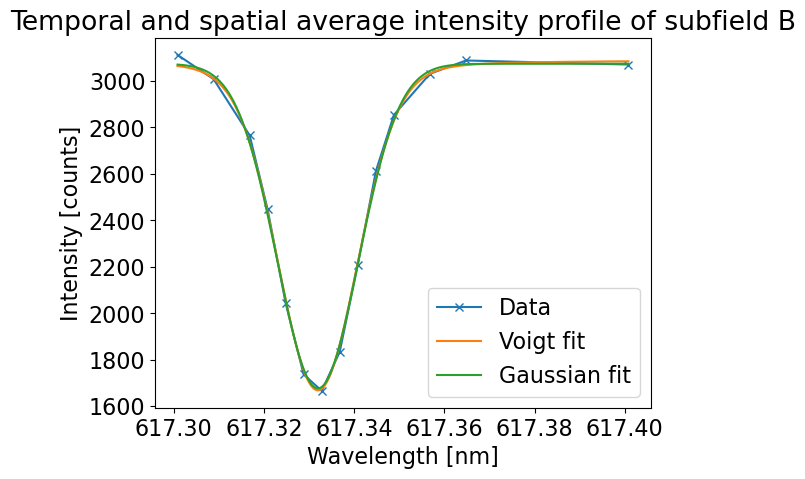

In [37]:
B_intensity_avg = np.average(subfield_B, axis=(0, 2, 3))

B_voigt_t0 = tt.time()
x_voigt, B_voigt_avg = _fit_voigt(wavelength, B_intensity_avg, nump = 1000, thr = 5)
B_voigt_tf = tt.time()
print(f"Voigt fit time: {B_voigt_tf - B_voigt_t0:.4f} s")

B_gaussian_t0 = tt.time()
x_gaussian, B_gaussian_avg = _fit_gaussian(wavelength, B_intensity_avg, nump = 1000, thr = 5)
B_gaussian_tf = tt.time()
print(f"Gaussian fit time: {B_gaussian_tf - B_gaussian_t0:.4f} s")

plt.plot(wavelength, B_intensity_avg, marker = "x", label="Data")
plt.plot(x_voigt, B_voigt_avg, label="Voigt fit")
plt.plot(x_gaussian, B_gaussian_avg, label="Gaussian fit")
plt.title("Temporal and spatial average intensity profile of subfield B")
plt.xlabel("Wavelength [nm]")
plt.ylabel("Intensity [counts]")
plt.legend()
plt.show()

### 4.2 Temporal and spatially averaged intensity profile

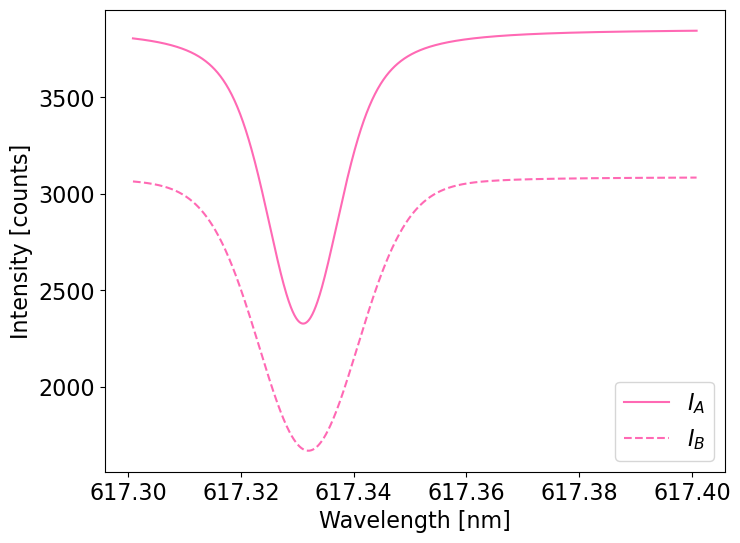

In [38]:
fig, ax = plt.subplots(figsize = (8, 6))
ax.plot(x_voigt, A_voigt_avg, label="$I_A$", color = "hotpink")
ax.plot(x_voigt, B_voigt_avg, label="$I_B$", color = "hotpink",  ls = "--")
ax.set_xlabel("Wavelength [nm]")
ax.set_ylabel("Intensity [counts]")
ax.legend(loc = "lower right")
# plt.savefig("figures/temp_spat_avg_voigt_intensity.png")
plt.show()

### 4.2.1 Error analysis of temporally and spatially averaged intensity profile

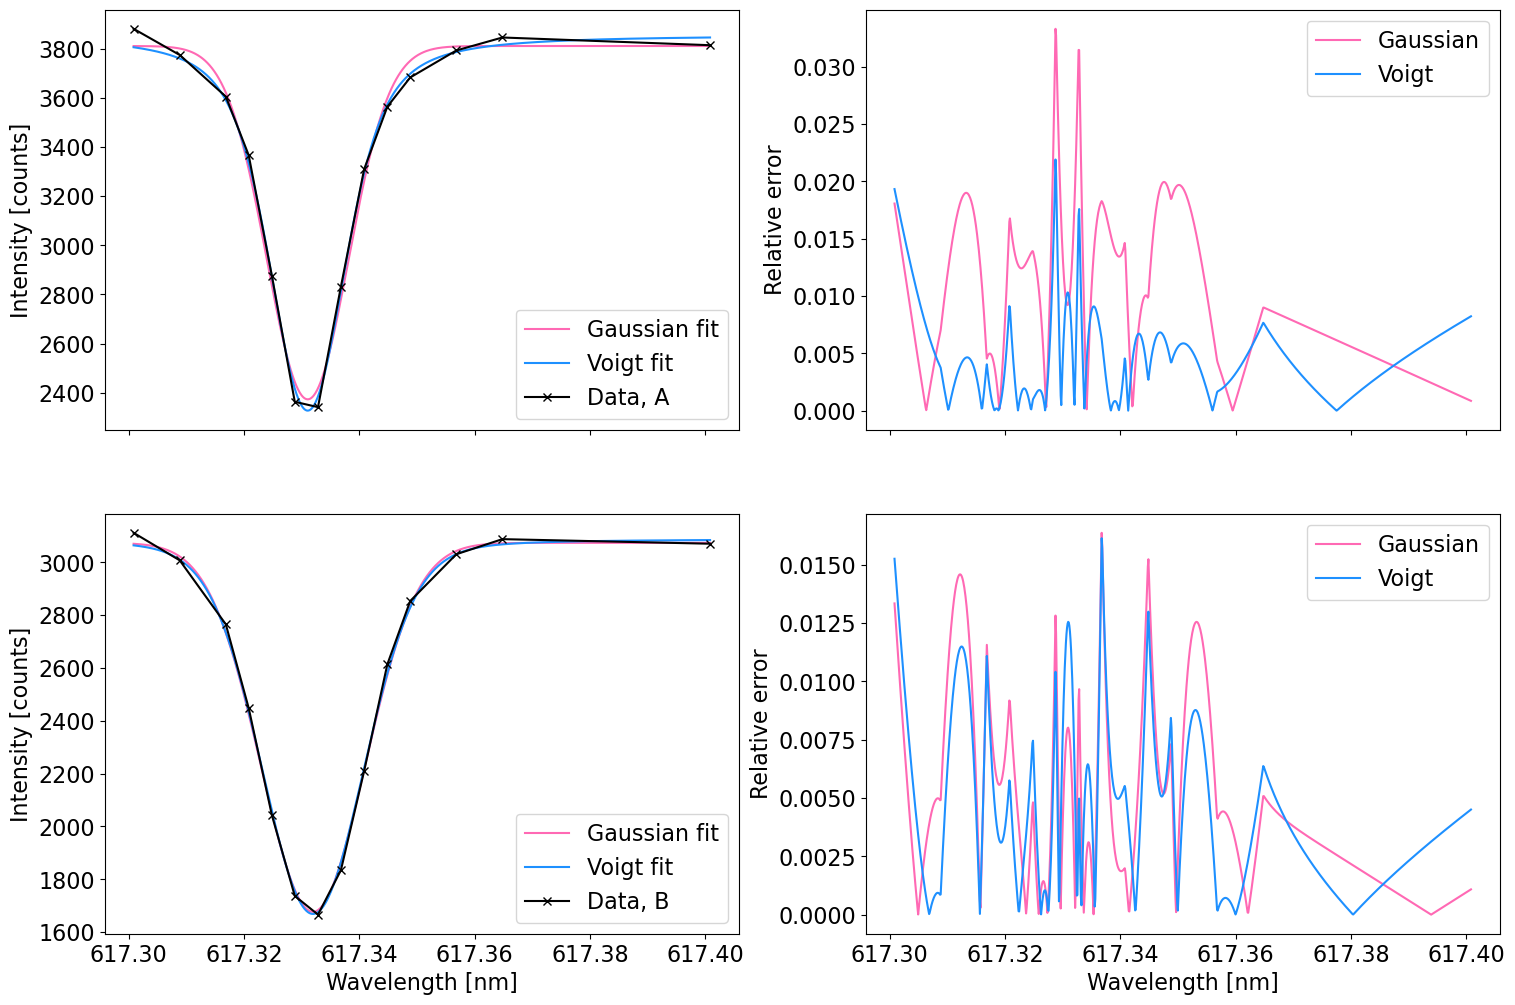

In [39]:
dataset = [np.average(subfield_A, axis = (0, 2, 3)), 
           np.average(subfield_B, axis = (0, 2, 3))]

dataname = ["A", "B"]

fig, ax = plt.subplots(2, 2, sharex = True, figsize = (18, 12))
for i in range(len(dataset)):

    # Create the interpolator using linear interpolation
    y_data = dataset[i]
    x_data = wavelength
    x_interpolated = np.linspace(x_data.min(), x_data.max(), 1000)
    interpolator = interp1d(x_data, y_data, kind='linear')

    # Use the interpolator to compute y values at new x points
    y_interpolated = interpolator(x_interpolated)

    # Parameters for curve fit
    background_level_guess = np.max(y_data)                             # Baseline level
    amplitude_guess = - (np.max(y_data) - np.min(y_data))    # Dip depth
    mean_guess = np.mean(wavelength)                                               # Center of the dip

    # Find FWHM
    peak_max = np.max(y_data) - np.min(y_data)
    half_max = peak_max / 2 + np.min(y_data)
    thr = 5
    indices = np.logical_and(y_interpolated > half_max - thr, y_interpolated < half_max + thr)
    search = np.where(indices == True)[0]
    if search.size < 2:
        print("No FWHM found")
        continue
    fwhm = x_interpolated[search[-1]] - x_interpolated[search[0]]
    sigma_guess =  fwhm       # Width of the Gaussian component
    gamma_guess = sigma_guess

    # gaussian
    initial_guesses_gauss = [amplitude_guess, mean_guess, sigma_guess, background_level_guess]
    popt_gauss, pcov_gauss = curve_fit(_gaussian, x_interpolated, y_interpolated, p0=initial_guesses_gauss, maxfev=5000)

    # voigt
    initial_guesses_voigt = [amplitude_guess, mean_guess, sigma_guess, gamma_guess, background_level_guess]
    popt_voigt, pcov_voigt = curve_fit(_voigt, x_interpolated, y_interpolated, p0=initial_guesses_voigt, maxfev=5000)

    abs_err_gauss = np.abs( _gaussian(x_interpolated, *popt_gauss) - y_interpolated ) / y_interpolated
    abs_err_voigt = np.abs( _voigt(x_interpolated, *popt_voigt) - y_interpolated ) / y_interpolated

    ax[i, 0].plot(x_interpolated, _gaussian(x_interpolated, *popt_gauss), color = 'hotpink', ls = '-', label=f'Gaussian fit')
    ax[i, 0].plot(x_interpolated, _voigt(x_interpolated, *popt_voigt), color='dodgerblue', ls ='-', label=f'Voigt fit')
    ax[i, 0].plot(x_data, y_data, 'kx-', label=f'Data, {dataname[i]}')
    ax[i, 0].legend()

    ax[i, 1].plot(x_interpolated, abs_err_gauss, color = 'hotpink', ls = '-', label='Gaussian')
    ax[i, 1].plot(x_interpolated, abs_err_voigt, color = 'dodgerblue', ls = '-', label='Voigt')
    ax[i, 1].legend()

    if i > 0:
        ax[i, 0].set_xlabel("Wavelength [nm]")
        ax[i, 1].set_xlabel("Wavelength [nm]")
    ax[i, 0].set_ylabel("Intensity [counts]")
    ax[i, 1].set_ylabel("Relative error")

    # plt.savefig("figures/rel_err_gauss_voigt.png")
    
plt.show()

Peak intensity value, subfield A: 3829.9582386861193 counts
Peak intensity value, subfield B: 3069.9476772608564 counts
Difference in peak intensity values: 760.010561425263 counts


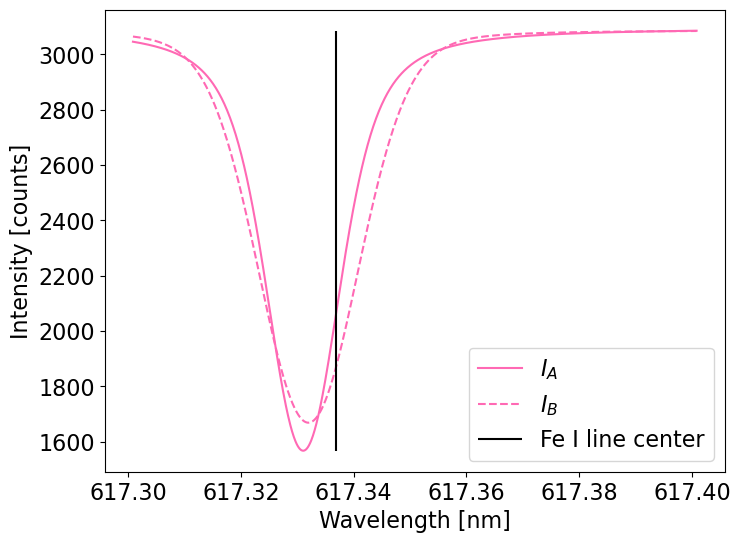

In [40]:
counts, bin_edges = np.histogram(A_voigt_avg, bins = 100)
max_count_index_A = np.argmax(counts)
peak_intensity_value_A = bin_edges[max_count_index_A]
print(f"Peak intensity value, subfield A: {peak_intensity_value_A} counts")

counts, bin_edges = np.histogram(B_voigt_avg, bins = 100)
max_count_index_B = np.argmax(counts)
peak_intensity_value_B = bin_edges[max_count_index_B]
print(f"Peak intensity value, subfield B: {peak_intensity_value_B} counts")

diff = np.abs(peak_intensity_value_A - peak_intensity_value_B)
print(f"Difference in peak intensity values: {diff} counts")

fig, ax = plt.subplots(figsize = (8, 6))
ax.plot(x_voigt, A_voigt_avg - diff, label="$I_A$", color = "hotpink")
ax.plot(x_voigt, B_voigt_avg, label="$I_B$", color = "hotpink", ls = "--")
ax.vlines(central_lmbda, A_voigt_avg.min() - diff, A_voigt_avg.max() - diff, color = "k", ls = "solid", label="Fe I line center")
ax.set_xlabel("Wavelength [nm]")
ax.set_ylabel("Intensity [counts]")
ax.legend(loc = "lower right")
# plt.savefig("figures/temp_spat_avg_voigt_intensity_scaled.png")
plt.show()

### 4.3 Spatially averaged intensity profile (Gaussian)(Doppler maps)

In [41]:
thr = 8
nump = 1000
intensity_avg_A_gaussian = np.zeros((time.size, nump))
x_1000 = np.linspace(wavelength.min(), wavelength.max(), nump)
for t in range(time.size):
    y_data = np.average(subfield_A[t, :], axis = (1, 2))
    x_gauss, y_gauss = _fit_gaussian(wavelength, y_data, nump, thr)
    intensity_avg_A_gaussian[t] = y_gauss

In [42]:
thr = 8
nump = 1000
intensity_avg_B_gaussian = np.zeros((time.size, nump))
x_1000 = np.linspace(wavelength.min(), wavelength.max(), nump)
for t in range(time.size):
    y_data = np.average(subfield_B[t, :], axis = (1, 2))
    x_gauss, y_gauss = _fit_gaussian(wavelength, y_data, nump, thr)
    intensity_avg_B_gaussian[t] = y_gauss

In [43]:
thr = 8
nump = 1000
intensity_avg_FOV_gaussian = np.zeros((time.size, nump))
x_1000 = np.linspace(wavelength.min(), wavelength.max(), nump)
for t in range(time.size):
    y_data = np.average(intensity[t, :], axis = (1, 2))
    x_gauss, y_gauss = _fit_gaussian(wavelength, y_data, nump, thr)
    intensity_avg_FOV_gaussian[t] = y_gauss

## 05 Dopplergram

In [44]:
def create_doppler_maps(data, intensity_avg, time_step, nump, thr):
    d_map = np.zeros((data.shape[2], data.shape[3]))
    for x_idx in range(data.shape[3]):
        for y_idx in range(data.shape[2]):
            # pixel intensity
            pixel_intensity = data[time_step, :, y_idx, x_idx]
            x_gaussian, y_gaussian = _fit_gaussian(wavelength, pixel_intensity, nump, thr)
            min_idx_pixel = np.argmin(y_gaussian)

            # finding line core of spatially averaged intensity
            min_idx_avg = np.argmin(intensity_avg[time_step])

            delta_lambda = x_gaussian[min_idx_pixel]*units.nm - x_gaussian[min_idx_avg]*units.nm
            v = delta_lambda.to(units.m) / (x_gaussian[min_idx_avg]*units.nm).to(units.m) * c
            d_map[y_idx, x_idx] = (v.to(units.km/units.s)).value

    return d_map

### 5.1 Saving data cube of Doppler maps as .npy

In [45]:
# doppler_cube_A = np.zeros((time.size, subfield_A.shape[2], subfield_A.shape[3]))
# for t in range(len(time)):
#     print(f"Time step: {t}")
#     doppler_cube_A[t] = create_doppler_maps(subfield_A, xy_A_min, xy_A_max, intensity_avg_A_gaussian, time_step=t, nump=1000, thr=15, suptitle="Subfield A", folder = "intensity_doppler_map_A", filename = "intensity_doppler_map_A", plot=True, savefig= True)
# np.save("doppler_cube_A.npy", doppler_cube_A)

In [46]:
# doppler_cube_B = np.zeros((time.size, subfield_B.shape[2], subfield_B.shape[3]))
# for t in range(len(time)):
#     print(f"Time step: {t}")
#     doppler_cube_B[t] = create_doppler_maps(subfield_B, intensity_avg_B_gaussian, time_step=t, nump=1000, thr=15, suptitle="Subfield B", folder = "doppler_map_B", filename = "doppler_map_B", plot=True, savefig= True)
# np.save("doppler_cube_B.npy", doppler_cube_B)

<span style="color:red"> The following cell should be ran on an ITA cluster! <span>

In [47]:
# doppler_cube_FOV = np.zeros((time.size, intensity.shape[2], intensity.shape[3]))
# for t in range(len(time)):
#     print(f"Time step: {t}")
#     doppler_cube_FOV[t] = create_doppler_maps(intensity, intensity_avg_FOV_gaussian, time_step=t, nump=1000, thr=15)
# np.save("doppler_cube_FOV.npy", doppler_cube_FOV)

### 5.2 Loading Doppler cubes

In [48]:
doppler_cube_A = np.load("doppler_cube_A.npy")
doppler_cube_B = np.load("doppler_cube_B.npy")

In [49]:
print(np.min(doppler_cube_A), np.max(doppler_cube_A))
print(np.min(doppler_cube_B), np.max(doppler_cube_B))

-3.158961969750567 2.624367980180884
-1.2149832063911414 1.6037783524439513


In [50]:
# for t in range(time.size):
#     fig, ax = plt.subplots(figsize = (8, 6))
#     norm = mpl.colors.TwoSlopeNorm(vmin=doppler_cube_A.min(), vcenter=0, vmax=doppler_cube_A.max())
#     im = ax.imshow(doppler_cube_A[t, :, :], cmap = "seismic", norm = norm, origin="lower", extent = [np.min(x_subfield_A), np.max(x_subfield_A), np.min(y_subfield_A), np.max(y_subfield_A)])
#     fig.colorbar(im, ax=ax, label="Doppler velocity [km/s]", fraction=0.046, pad=0.04)
#     ax.set_xlabel("x [arcsec]"); ax.set_ylabel("y [arcsec]")
#     ax.set_title(f"Subfield A, t[{t}] = {time_s[t]: .3f} s")
#     fig.tight_layout()
#     plt.savefig(f"figures/doppler_map_A/doppler_map_A_{t:04d}.png")

In [51]:
# for t in range(time.size):
#     fig, ax = plt.subplots(figsize = (8, 6))
#     norm = mpl.colors.TwoSlopeNorm(vmin=doppler_cube_B.min(), vcenter=0, vmax=doppler_cube_B.max())
#     im = ax.imshow(doppler_cube_B[t, :, :], cmap = "seismic", norm = norm, origin="lower", extent = [np.min(x_subfield_B), np.max(x_subfield_B), np.min(y_subfield_B), np.max(y_subfield_B)])
#     fig.colorbar(im, ax=ax, label="Doppler velocity [km/s]", fraction=0.046, pad=0.04)
#     ax.set_xlabel("x [arcsec]"); ax.set_ylabel("y [arcsec]")
#     ax.set_title(f"Subfield B, t[{t}] = {time_s[t]: .3f} s")
#     fig.tight_layout()
#     plt.savefig(f"figure/doppler_map_B/doppler_map_B_{t:04d}.png")

### 5.2 Histogram of Doppler velocities

Peak value for subfield A: 0.16645275146001692 km/s
True
Peak value for subfield B: -0.1579476218279816 km/s
False


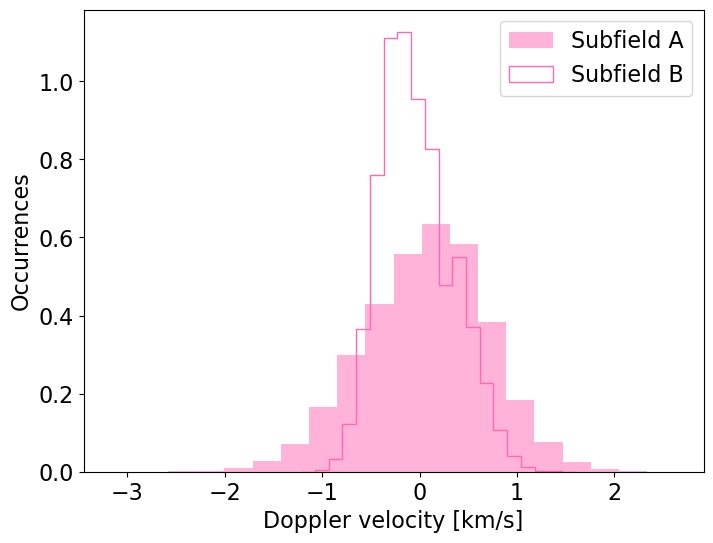

In [52]:
fig, ax = plt.subplots(figsize = (8, 6))
bins = 20
counts_A, bin_edges_A = np.histogram(doppler_cube_A, bins=bins)
ax.hist(doppler_cube_A.flatten(), bins=bin_edges_A, label="Subfield A", density = True, histtype = 'bar', alpha = 0.5,  color = "hotpink")

# Find the peak for Subfield A
peak_index_A = np.argmax(counts_A)
peak_x_value_A = bin_edges_A[peak_index_A] + (bin_edges_A[peak_index_A + 1] - bin_edges_A[peak_index_A]) / 2
print(f"Peak value for subfield A: {peak_x_value_A} km/s")

density_A = counts_A / (sum(counts_A) * np.diff(bin_edges_A))
print(np.sum(density_A*np.diff(bin_edges_A)) == 1)



counts_B, bin_edges_B = np.histogram(doppler_cube_B, bins=bins)
ax.hist(doppler_cube_B.flatten(), bins=bin_edges_B, label="Subfield B", density=True, histtype='step', color='hotpink')

# Find the peak for Subfield B
peak_index_B = np.argmax(counts_B)
peak_x_value_B = bin_edges_B[peak_index_B] + (bin_edges_B[peak_index_B + 1] - bin_edges_B[peak_index_B]) / 2
print(f"Peak value for subfield B: {peak_x_value_B} km/s")


density_B = counts_B / (sum(counts_B) * np.diff(bin_edges_B))
print(np.sum(density_B*np.diff(bin_edges_B)) == 1)

ax.legend()
ax.set_xlabel("Doppler velocity [km/s]")
ax.set_ylabel("Occurrences")
plt.savefig("figures/doppler_histogram.png");

## 06 Equivalent width

### 6.1 Integration range

In [53]:
def int_range(intensity_data, wavelengths):
    counts, bin_edges = np.histogram(intensity_data, bins=30)
    max_count_index = np.argmax(counts)
    peak_intensity_value = bin_edges[max_count_index] #np.max(intensity_data) 


    line_center_idx = np.where(intensity_data == np.min(intensity_data))[0][0]
    line_center_wavelength = wavelengths[line_center_idx]

    cut_off_min = 0

    for wav in wavelengths[:line_center_idx]:
        wav_idx = np.where(wavelengths == wav)[0][0]
        if intensity_data[wav_idx] < peak_intensity_value:
            cut_off_min = wav_idx
            break

    cut_off_max = 0
    for wav in wavelengths[line_center_idx:][::-1]:
        wav_idx = np.where(wavelengths == wav)[0][0]
        if intensity_data[wav_idx] < peak_intensity_value:
            cut_off_max = wav_idx
            break

    return cut_off_min, cut_off_max, line_center_idx, peak_intensity_value

In [54]:
def calculate_ew_val(data, nump, thr):
    x_voigt, y_voigt = _fit_voigt(wavelength, data, nump, thr)

    cut_off_min, cut_off_max, line_center_idx, I_cont = int_range(y_voigt, x_voigt)
    ew = np.trapz(1 - y_voigt[cut_off_min:cut_off_max] / I_cont, x_voigt[cut_off_min:cut_off_max]) * units.nm

    return ew.to(units.mAA).value

### 6.2 Temporal evolution of spatially averaged equivalent width

/tmp/ipykernel_2298797/3978198344.py:3: RuntimeWarning: overflow encountered in multiply
  return amplitude * np.real(wofz(z)) / (sigma * np.sqrt(2 * np.pi)) + background
/tmp/ipykernel_2298797/3978198344.py:3: RuntimeWarning: overflow encountered in divide
  return amplitude * np.real(wofz(z)) / (sigma * np.sqrt(2 * np.pi)) + background


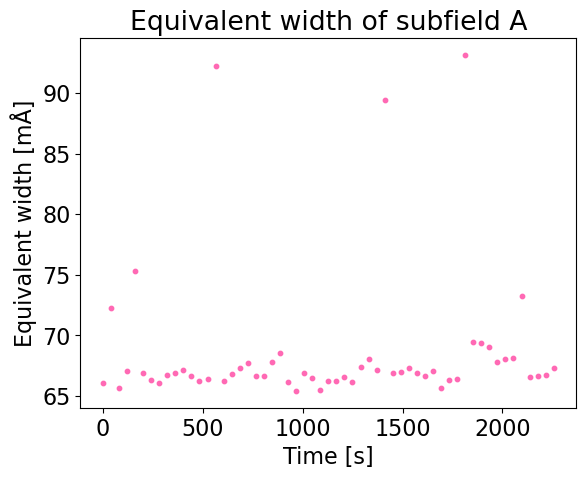

Average EW A: 68.56335768483186 mÅ
5.715013880306424
65.40636424169907 93.15001326664152
3.156993443132791 24.586655581809666


In [55]:
ew_vals_A = np.zeros(time.size)
for t in range(len(time)):
    spat_avg_A = np.average(subfield_A[t, :], axis = (1, 2))
    ew_vals_A[t] = calculate_ew_val(spat_avg_A, nump=1000, thr=15)
    
    plt.scatter(time_s[t], ew_vals_A[t], color = "hotpink", s = 10)
plt.xlabel("Time [s]")
plt.ylabel("Equivalent width [mÅ]")
plt.title("Equivalent width of subfield A")
# plt.savefig("figure/ew_A.png")
plt.show()

print(f"Average EW A: {np.mean(ew_vals_A)} mÅ")
print(np.std(ew_vals_A))
print(np.min(ew_vals_A), np.max(ew_vals_A))
print(np.mean(ew_vals_A) - np.min(ew_vals_A), np.max(ew_vals_A) - np.mean(ew_vals_A))

/tmp/ipykernel_2298797/3978198344.py:3: RuntimeWarning: overflow encountered in multiply
  return amplitude * np.real(wofz(z)) / (sigma * np.sqrt(2 * np.pi)) + background
/tmp/ipykernel_2298797/3978198344.py:3: RuntimeWarning: overflow encountered in divide
  return amplitude * np.real(wofz(z)) / (sigma * np.sqrt(2 * np.pi)) + background


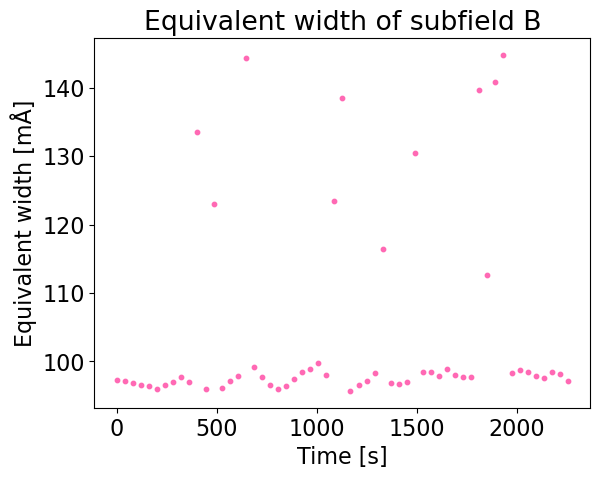

Average EW B: 104.04915586167402 mÅ
14.30909381894539
95.67178255803736 144.8097467309659
8.37737330363666 40.76059086929189


In [56]:
ew_vals_B = np.zeros(time.size)
for t in range(len(time)):
    spat_avg_B = np.average(subfield_B[t, :], axis = (1, 2))
    ew_vals_B[t] = calculate_ew_val(spat_avg_B, nump=1000, thr=15)
    #print(f"Time step: {t}, EW: {ew_vals_B[t]} mAA")
    plt.scatter(time_s[t], ew_vals_B[t], color = "hotpink", s = 10)
plt.xlabel("Time [s]")
plt.ylabel("Equivalent width [mÅ]")
plt.title("Equivalent width of subfield B")
# plt.savefig("figure/ew_B.png")
plt.show()
print(f"Average EW B: {np.mean(ew_vals_B)} mÅ")
print(np.std(ew_vals_B))
print(np.min(ew_vals_B), np.max(ew_vals_B))
print(np.mean(ew_vals_B) - np.min(ew_vals_B), np.max(ew_vals_B) - np.mean(ew_vals_B))

### 6.3 Equivalent width maps for each time step

In [57]:
def create_ew_maps(data, time_step, nump, thr):
    ew_map = np.zeros((data.shape[2], data.shape[3]))
    for x_idx in range(data.shape[3]):
        for y_idx in range(data.shape[2]):
            # pixel intensity
            pixel_intensity = data[time_step, :, y_idx, x_idx]
            x_gaussian, y_gaussian = _fit_gaussian(wavelength, pixel_intensity, nump, thr)

            cut_off_min, cut_off_max, line_center_idx, I_cont = int_range(y_gaussian, x_gaussian)
            ew = np.trapz(1 - y_gaussian[cut_off_min:cut_off_max] / I_cont, x_gaussian[cut_off_min:cut_off_max]) * units.nm
            ew_map[y_idx, x_idx] = ew.to(units.mAA).value
    return ew_map

In [58]:
# ew_cube_A = np.zeros((time.size, subfield_A.shape[2], subfield_A.shape[3]))
# for t in range(len(time)):
#     print(f"Time step: {t}")
#     ew_map = create_ew_maps(subfield_A, t, nump=1000, thr=15)
#     ew_cube_A[t] = ew_map
# np.save("ew_cube_A.npy", ew_cube_A)

In [35]:
# ew_cube_B = np.zeros((time.size, subfield_B.shape[2], subfield_B.shape[3]))
# for t in range(len(time)):
#     print(f"Time step: {t}")
#     ew_map = create_ew_maps(subfield_B, t, nump=1000, thr=15)
#     ew_cube_B[t] = ew_map
# np.save("ew_cube_B.npy", ew_cube_B)

In [ ]:
ew_cube_A = np.load("ew_cube_A.npy")
ew_cube_B = np.load("ew_cube_B.npy")

(57, 86, 86)


### 6.3.1 EW vs Doppler velocity, subfield A (no mask)

In [37]:
# for t in range(len(time)):
#     fig, ax = plt.subplots(figsize = (8, 6))
#     print(f"Time step: {t}")

#     x = ew_cube_A[t, :, :].flatten()
#     y = doppler_cube_A[t, :, :].flatten()

#     ax.scatter(x, y, alpha = .1, color = "hotpink")


#     coefficients = np.polyfit(x, y, 1)
#     slope, intercept = coefficients

#     fitted_line = slope * x + intercept

#     ax.plot(x, fitted_line, color='black', label='Linear fit')

#     ax.set_xlim(np.min(ew_cube_A), np.max(ew_cube_A))
#     ax.set_ylim(np.min(doppler_cube_A), np.max(doppler_cube_A))
#     ax.set_xlabel("Equivalent width [m$\AA$]")
#     ax.set_ylabel("Doppler velocity [km/s]")
#     ax.set_title(f't[{t}]={time_s[t]: .3f} s')
#     plt.legend(loc ='upper right')
#     plt.savefig(f"figures/ew_doppler_A/ew_doppler_A_{t:04d}.png")
#     #plt.show()

### 6.3.1 EW vs Doppler velocity, subfield A (w/ mask)

In [82]:
# for t in range(time.size):
#     fig, ax = plt.subplots(figsize = (8, 6))
#     print(f"Time step: {t}")

#     # Split data based on intensity
#     x_high = x[mask == 1]
#     y_high = y[mask == 1]

#     x_low = x[mask == 0]
#     y_low = y[mask == 0]

#     x = ew_cube_A[t, :, :].flatten()
#     y = doppler_cube_A[t, :, :].flatten()
#     mask = intensity_mask_A[t].flatten()

#     # ax.scatter(x, y, alpha = .1, color = "hotpink")
#     ax.scatter(x[mask == 1], y[mask == 1], alpha=0.1, color='hotpink', label=r'$I > \frac{1}{2} I_{max}$')
#     ax.scatter(x[mask == 0], y[mask == 0], alpha=0.1, color='gray', label=r'$I \leq \frac{1}{2} I_{max}$')

#     # Linear fit for high-intensity points
#     if len(x_high) > 1:
#         slope_high, intercept_high = np.polyfit(x_high, y_high, 1)
#         ax.plot(x_high, slope_high * x_high + intercept_high, color='deeppink', label='Linear fit (I > ½ max)')

#     # Linear fit for low-intensity points
#     if len(x_low) > 1:
#         slope_low, intercept_low = np.polyfit(x_low, y_low, 1)
#         ax.plot(x_low, slope_low * x_low + intercept_low, color='dimgray', label='Linear fit (I ≤ ½ max)')

#     # Axes settings
#     ax.set_xlim(np.min(ew_cube_A), np.max(ew_cube_A))
#     ax.set_ylim(np.min(doppler_cube_A), np.max(doppler_cube_A))
#     ax.set_xlabel("Equivalent width [m$\AA$]")
#     ax.set_ylabel("Doppler velocity [km/s]")
#     ax.set_title(f't[{t}] = {time_s[t]:.3f} s')
#     ax.legend(loc='lower left')
#     plt.savefig(f"figures/ew_doppler_mask_A/ew_doppler_mask_A_{t:04d}.png")
#     plt.show()


### 6.3.2 EW vs. Doppler velocity, subfield B

In [39]:
# for t in range(len(time)):
#     fig, ax = plt.subplots(figsize = (8, 6))
#     print(f"Time step: {t}")

#     x = ew_cube_B[t, :, :].flatten()
#     y = doppler_cube_B[t, :, :].flatten()

#     ax.scatter(x, y, alpha = .1, color = "hotpink")


#     coefficients = np.polyfit(x, y, 1)
#     slope, intercept = coefficients

#     fitted_line = slope * x + intercept

#     ax.plot(x, fitted_line, color='black', label='Linear fit')

#     ax.set_xlim(np.min(ew_cube_B), np.max(ew_cube_B))
#     ax.set_ylim(np.min(doppler_cube_B), np.max(doppler_cube_B))
#     ax.set_xlabel("Equivalent width [m$\AA$]")
#     ax.set_ylabel("Doppler velocity [km/s]")
#     ax.set_title(f't[{t}]={time_s[t]: .3f} s')
#     plt.legend(loc='upper right')
#     #plt.savefig(f"figures/ew_doppler_B/ew_doppler_B_{t:04d}.png")
#     #plt.show()

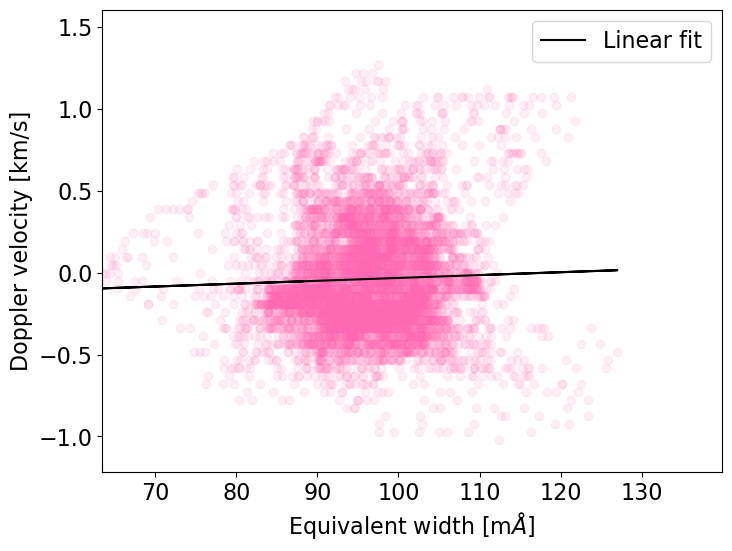

In [40]:
fig, ax = plt.subplots(figsize = (8, 6))

t = len(time) - 1
x = ew_cube_B[t, :, :].flatten()
y = doppler_cube_B[t, :, :].flatten()

ax.scatter(x, y, alpha = .1, color = "hotpink")


coefficients = np.polyfit(x, y, 1)
slope, intercept = coefficients

fitted_line = slope * x + intercept

ax.plot(x, fitted_line, color='black', label='Linear fit')

ax.set_xlim(np.min(ew_cube_B), np.max(ew_cube_B))
ax.set_ylim(np.min(doppler_cube_B), np.max(doppler_cube_B))
ax.set_xlabel("Equivalent width [m$\AA$]")
ax.set_ylabel("Doppler velocity [km/s]")
plt.legend(loc ='upper right')
plt.savefig(f"figures/ew_doppler_B_tf.png")

## Numerical model of G2V star

In [4]:
G2V_50G_li = h5py.File("/mn/stornext/d19/RoCS/svenwe/lecture/AST5770/data/simsts_G2V/simsts_G2V_50G_lineintensity_FeI6173.h5", "r")
G2V_50G_cont = h5py.File("/mn/stornext/d19/RoCS/svenwe/lecture/AST5770/data/simsts_G2V/simsts_G2V_50G_continuumintensity.h5", "r")
G2V_50G = h5py.File("/mn/stornext/d19/RoCS/svenwe/lecture/AST5770/data/simsts_G2V/simsts_G2V_50G.h5", "r")
G2V_50G_li.keys()

<KeysViewHDF5 ['description', 'icontinuum', 'intensity', 'lambda0', 'time', 'unit', 'wavelength', 'x', 'y']>

In [5]:
print(G2V_50G_li["wavelength"][:])
print(G2V_50G_cont["wavelength"][:])

[617.294   617.2942  617.2944  617.29456 617.2948  617.295   617.29517
 617.29535 617.2956  617.2958  617.296   617.2962  617.2964  617.2966
 617.29675 617.297   617.2972  617.29736 617.2976  617.2978  617.298
 617.2982  617.2984  617.2986  617.29877 617.29895 617.2992  617.2994
 617.29956 617.2998  617.3     617.3002  617.3004  617.3006  617.3008
 617.30096 617.30115 617.3014  617.3016  617.3018  617.302   617.3022
 617.30237 617.3026  617.3028  617.303   617.30316 617.30334 617.3036
 617.3038  617.304   617.3042  617.3044  617.30457 617.3048  617.305
 617.3052  617.30536 617.30554 617.3058  617.306   617.3062  617.3064
 617.3066  617.30676 617.307   617.3072  617.3074  617.30756 617.30774
 617.308   617.3082  617.3084  617.3086  617.3088  617.30896 617.3092
 617.3094  617.3096  617.30975 617.30994 617.3102  617.3104  617.3106
 617.3108  617.311   617.31116 617.3114  617.3116  617.31177 617.31195
 617.3122  617.3124  617.3126  617.3128  617.313   617.3132  617.31335
 617.3136  617.313

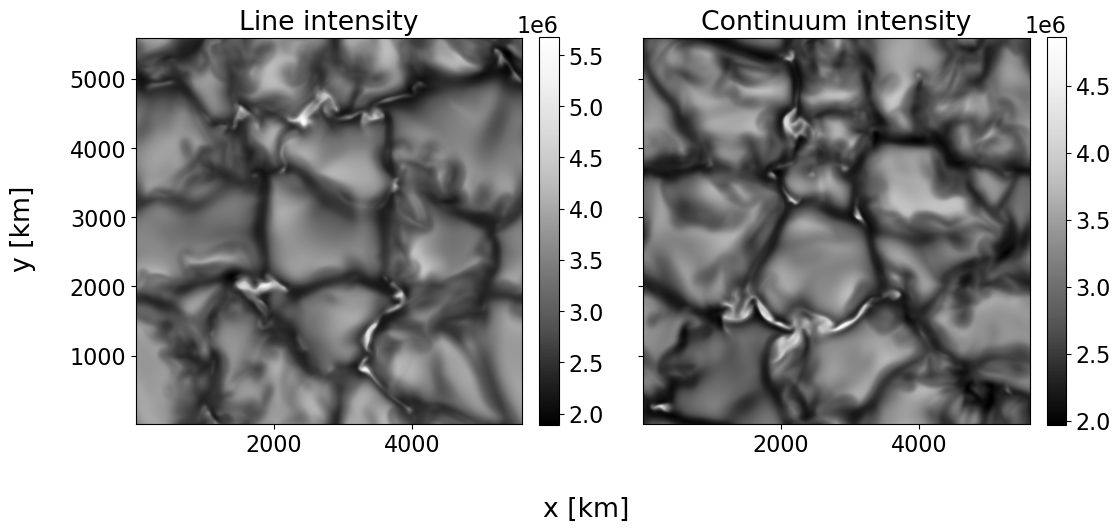

In [6]:
fig, ax = plt.subplots(1, 2, figsize = (12, 6), sharey=True)
fig.supxlabel("x [km]"); fig.supylabel("y [km]")

im_li = ax[0].imshow(G2V_50G_li["intensity"][400, :, :], origin="lower", extent = [np.min(G2V_50G_li["x"])/1e5, np.max(G2V_50G_li["x"])/1e5, np.min(G2V_50G_li["y"])/1e5, np.max(G2V_50G_li["y"])/1e5])
ax[0].set_title("Line intensity")
fig.colorbar(im_li, ax=ax[0], fraction=0.046, pad=0.04)

im_cont = ax[1].imshow(G2V_50G_cont["intensity"][12, :, :], origin="lower", extent = [np.min(G2V_50G_cont["x"])/1e5, np.max(G2V_50G_cont["x"])/1e5, np.min(G2V_50G_cont["y"])/1e5, np.max(G2V_50G_cont["y"])/1e5])
ax[1].set_title("Continuum intensity")
fig.colorbar(im_cont, ax=ax[1], fraction=0.046, pad=0.04)

In [7]:
# plt.imshow(G2V_50G_li["intensity"][0, :, :], origin="lower", cmap="plasma")
# plt.imshow(G2V_50G_cont["intensity"][0, :, :], origin="lower", cmap="plasma")

print(G2V_50G.keys())
print(G2V_50G["vz"].shape)
print(G2V_50G["z"].shape)
print(G2V_50G["z"][0], G2V_50G["z"][-1])

<KeysViewHDF5 ['bx', 'by', 'bz', 'description', 'dz', 'kappa', 'model_id', 'pgas', 'rho', 'tgas', 'time', 'unit', 'vx', 'vy', 'vz', 'x', 'y', 'z']>
(188, 400, 400)
(188,)
-136556300.0 87843700.0


In [8]:
surf = np.where(G2V_50G["z"][:] > 0)[0][0]
surf


114

In [9]:
G2V_50G["z"][84]

-35756304.0

In [15]:
# for height in range(surf - 10, surf + 10):  
#     fig, ax = plt.subplots(figsize=(8, 6))
#     ax.set_title(f"z = {G2V_50G['z'][height]:.2f} km")
#     ax.set_xlabel("x [km]"); ax.set_ylabel("y [km]")
#     im = ax.imshow(G2V_50G["vz"][height, :, :], origin="lower", vmin  = G2V_50G["vz"][:].min(), vmax = G2V_50G["vz"][:].max(), extent = [np.min(G2V_50G["x"])/1e5, np.max(G2V_50G["x"])/1e5, np.min(G2V_50G["y"])/1e5, np.max(G2V_50G["y"])/1e5], cmap="seismic")
#     fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="$v_z$ [km/s]")
#     plt.tight_layout()
#     plt.savefig(f"figures/intensity_G2V/intensity_G2V_{height:04d}.png")